In [4]:
# ============================================
# CELL 1 - Imports 
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Import lightning correctly
try:
    import lightning as pl
    print(f"✅ Lightning version : {pl.__version__}")
except:
    import pytorch_lightning as pl
    print(f"✅ PyTorch Lightning : {pl.__version__}")

print(f"✅ PyTorch version   : {torch.__version__}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device           : {device}")

✅ Lightning version : 2.6.1
✅ PyTorch version   : 2.11.0+cpu
🖥️  Device           : cpu


In [6]:
# ============================================
# CELL 2 - Load All CMAPSS Datasets
# ============================================

def load_cmapss(file_path, rul_path=None):
    """Load CMAPSS dataset and add RUL"""

    cols = ['engine_id', 'cycle'] + \
           [f'setting_{i}' for i in range(1, 4)] + \
           [f'sensor_{i}' for i in range(1, 22)]

    df = pd.read_csv(
        file_path,
        sep='\s+',
        header=None,
        names=cols,
        engine='python'
    )
    df.dropna(axis=1, how='all', inplace=True)

    # Add RUL
    max_cycle = df.groupby('engine_id')['cycle']\
                  .max().reset_index()
    max_cycle.columns = ['engine_id', 'max_cycle']
    df = df.merge(max_cycle, on='engine_id')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df.drop(columns=['max_cycle'], inplace=True)

    # Cap RUL at 125 (common practice)
    df['RUL'] = df['RUL'].clip(upper=125)

    return df

# Load train and test
train_df = load_cmapss('../data/train_FD001.txt')
test_df  = load_cmapss('../data/test_FD001.txt')

print(f"✅ Train shape: {train_df.shape}")
print(f"✅ Test shape : {test_df.shape}")
print(f"📊 Train engines: {train_df['engine_id'].nunique()}")
print(f"📊 Test engines : {test_df['engine_id'].nunique()}")
print(f"\n📊 Train RUL stats:")
print(train_df['RUL'].describe().round(2))

✅ Train shape: (20631, 27)
✅ Test shape : (13096, 27)
📊 Train engines: 100
📊 Test engines : 100

📊 Train RUL stats:
count    20631.00
mean        86.83
std         41.67
min          0.00
25%         51.00
50%        103.00
75%        125.00
max        125.00
Name: RUL, dtype: float64


In [7]:
# ============================================
# CELL 3 - Feature Selection
# ============================================

# Drop constant sensors
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_cols = [c for c in sensor_cols
               if c in train_df.columns
               and train_df[c].std() > 0.001]

setting_cols = ['setting_1', 'setting_2', 'setting_3']
setting_cols = [c for c in setting_cols
                if c in train_df.columns]

# All feature columns
feature_cols = setting_cols + sensor_cols

print(f"✅ Feature columns  : {len(feature_cols)}")
print(f"📊 Setting features : {len(setting_cols)}")
print(f"📊 Sensor features  : {len(sensor_cols)}")
print(f"\n📋 Features used: {feature_cols}")

✅ Feature columns  : 18
📊 Setting features : 3
📊 Sensor features  : 15

📋 Features used: ['setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [8]:
# ============================================
# CELL 4 - Scale Features
# ============================================

# Use MinMaxScaler for RUL forecasting
scaler = MinMaxScaler()

# Fit on training data only
train_df[feature_cols] = scaler.fit_transform(
    train_df[feature_cols]
)

# Transform test data
test_df[feature_cols] = scaler.transform(
    test_df[feature_cols]
)

# Scale RUL separately (0-1)
rul_scaler = MinMaxScaler()
train_df['RUL_scaled'] = rul_scaler.fit_transform(
    train_df[['RUL']]
)
test_df['RUL_scaled'] = rul_scaler.transform(
    test_df[['RUL']]
)

print(f"✅ Features scaled!")
print(f"📊 Feature range: [{train_df[feature_cols].min().min():.2f}, "
      f"{train_df[feature_cols].max().max():.2f}]")
print(f"📊 RUL range    : [{train_df['RUL_scaled'].min():.2f}, "
      f"{train_df['RUL_scaled'].max():.2f}]")

✅ Features scaled!
📊 Feature range: [0.00, 1.00]
📊 RUL range    : [0.00, 1.00]


In [9]:
# ============================================
# CELL 5 - Sliding Window Sequences
# ============================================

def create_sequences(df, feature_cols,
                     seq_len=30, target='RUL_scaled'):
    """
    Create sliding window sequences for LSTM
    Returns: X (sequences), y (RUL targets)
    """
    X_list = []
    y_list = []

    # Process each engine separately
    for engine_id in df['engine_id'].unique():
        engine_df = df[df['engine_id'] == engine_id]\
                      .reset_index(drop=True)

        features = engine_df[feature_cols].values
        targets  = engine_df[target].values

        # Create sliding windows
        for i in range(len(engine_df) - seq_len + 1):
            X_list.append(features[i:i+seq_len])
            y_list.append(targets[i+seq_len-1])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)

    return X, y

# Create sequences with different window sizes
SEQ_LENGTHS = [30, 60, 90]

for seq_len in SEQ_LENGTHS:
    X_temp, y_temp = create_sequences(
        train_df, feature_cols, seq_len=seq_len
    )
    print(f"Seq len {seq_len:3d} → "
          f"X: {X_temp.shape} | "
          f"y: {y_temp.shape}")

# Use seq_len = 30 (good balance)
SEQ_LEN = 30
X_train, y_train = create_sequences(
    train_df, feature_cols, seq_len=SEQ_LEN
)
X_test, y_test = create_sequences(
    test_df, feature_cols, seq_len=SEQ_LEN
)

print(f"\n✅ Using sequence length: {SEQ_LEN}")
print(f"📊 X_train: {X_train.shape}")
print(f"📊 y_train: {y_train.shape}")
print(f"📊 X_test : {X_test.shape}")
print(f"📊 y_test : {y_test.shape}")

Seq len  30 → X: (17731, 30, 18) | y: (17731,)
Seq len  60 → X: (14731, 60, 18) | y: (14731,)
Seq len  90 → X: (11731, 90, 18) | y: (11731,)

✅ Using sequence length: 30
📊 X_train: (17731, 30, 18)
📊 y_train: (17731,)
📊 X_test : (10196, 30, 18)
📊 y_test : (10196,)


In [10]:
# ============================================
# CELL 6 - Custom PyTorch Dataset
# ============================================

class RULDataset(Dataset):
    """Custom Dataset for RUL Forecasting"""

    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = RULDataset(X_train, y_train)
test_dataset  = RULDataset(X_test,  y_test)

print(f"✅ Train dataset size: {len(train_dataset)}")
print(f"✅ Test dataset size : {len(test_dataset)}")

# Test one sample
sample_X, sample_y = train_dataset[0]
print(f"\n📊 Sample X shape: {sample_X.shape}")
print(f"📊 Sample y value: {sample_y:.4f}")
print(f"📊 Sample RUL    : {rul_scaler.inverse_transform([[sample_y.item()]])[0][0]:.1f} cycles")

✅ Train dataset size: 17731
✅ Test dataset size : 10196

📊 Sample X shape: torch.Size([30, 18])
📊 Sample y value: 1.0000
📊 Sample RUL    : 125.0 cycles


In [11]:
# ============================================
# CELL 7 - PyTorch Lightning DataModule
# ============================================

class RULDataModule(pl.LightningDataModule):
    def __init__(self,
                 X_train, y_train,
                 X_test,  y_test,
                 batch_size=64,
                 val_split=0.2):

        super().__init__()
        self.X_train    = X_train
        self.y_train    = y_train
        self.X_test     = X_test
        self.y_test     = y_test
        self.batch_size = batch_size
        self.val_split  = val_split

    def setup(self, stage=None):
        full_dataset = RULDataset(self.X_train, self.y_train)

        val_size   = int(len(full_dataset) * self.val_split)
        train_size = len(full_dataset) - val_size

        self.train_dataset, self.val_dataset = \
            torch.utils.data.random_split(
                full_dataset, [train_size, val_size]
            )
        self.test_dataset = RULDataset(
            self.X_test, self.y_test
        )

        print(f"✅ DataModule setup!")
        print(f"   Train: {len(self.train_dataset)}")
        print(f"   Val  : {len(self.val_dataset)}")
        print(f"   Test : {len(self.test_dataset)}")

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=0
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=0
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=0
        )

# Initialize
dm = RULDataModule(
    X_train, y_train,
    X_test,  y_test,
    batch_size=64
)
dm.setup()

✅ DataModule setup!
   Train: 14185
   Val  : 3546
   Test : 10196


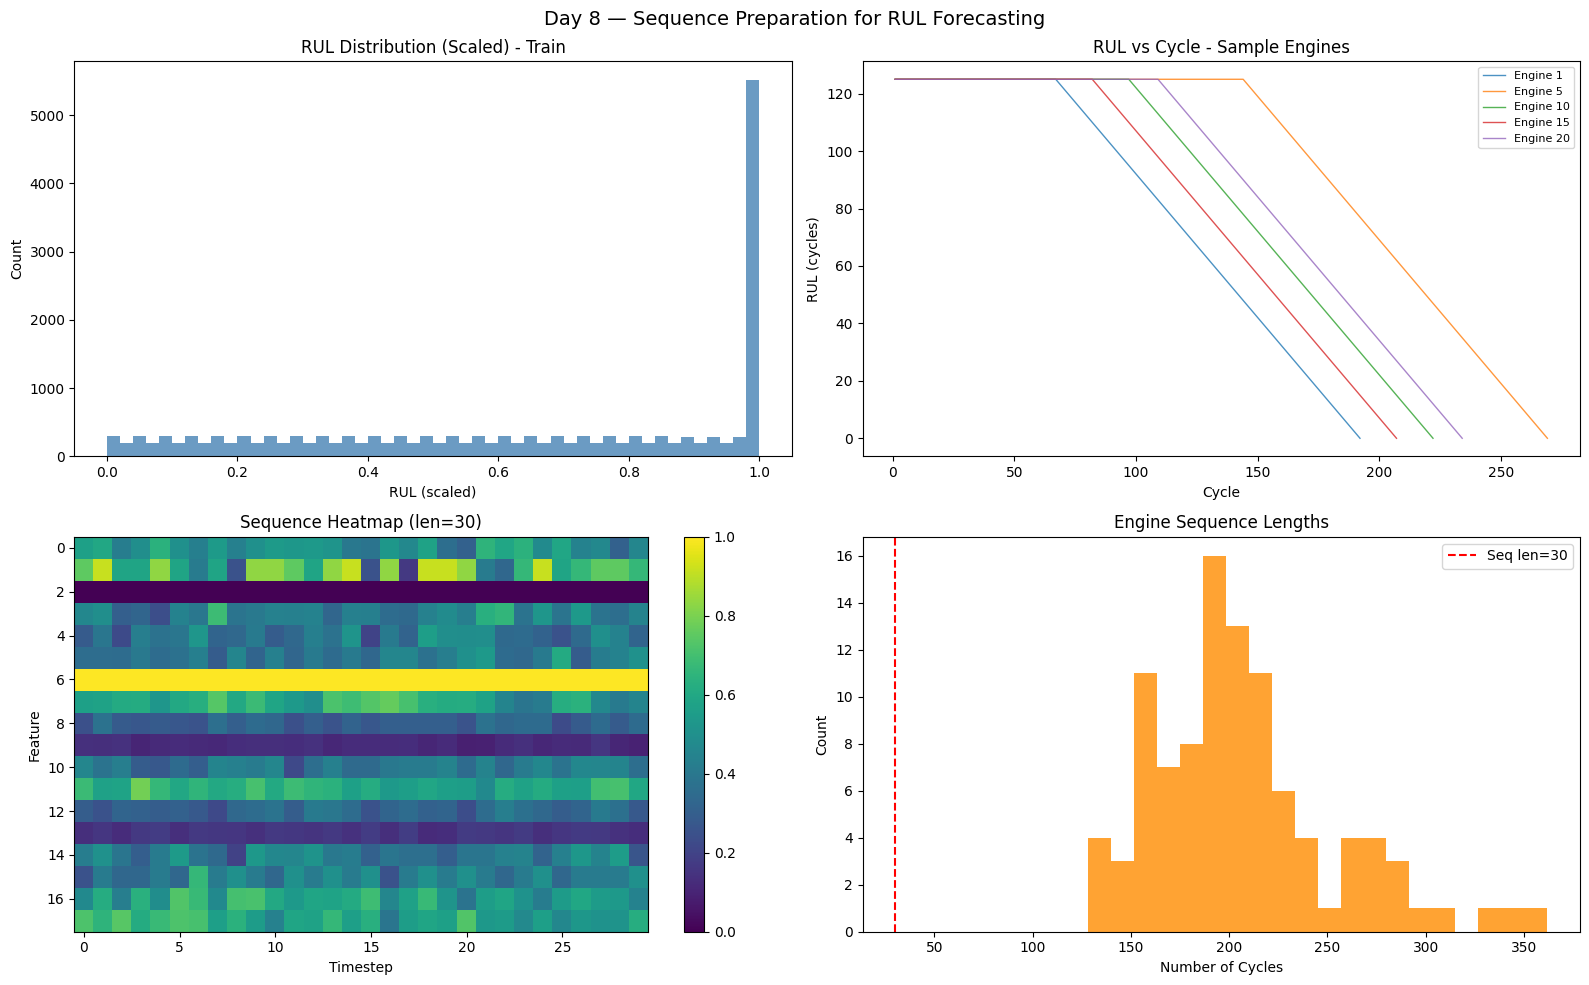

✅ Plots saved!


In [12]:
# ============================================
# CELL 8 - Visualize Sequences
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: RUL Distribution
axes[0,0].hist(y_train, bins=50,
               color='steelblue', alpha=0.8)
axes[0,0].set_title('RUL Distribution (Scaled) - Train')
axes[0,0].set_xlabel('RUL (scaled)')
axes[0,0].set_ylabel('Count')

# Plot 2: RUL vs Cycle for sample engines
axes[0,1].set_title('RUL vs Cycle - Sample Engines')
for eng_id in [1, 5, 10, 15, 20]:
    eng = train_df[train_df['engine_id'] == eng_id]
    axes[0,1].plot(eng['cycle'], eng['RUL'],
                   linewidth=1, alpha=0.8,
                   label=f'Engine {eng_id}')
axes[0,1].set_xlabel('Cycle')
axes[0,1].set_ylabel('RUL (cycles)')
axes[0,1].legend(fontsize=8)

# Plot 3: Sequence heatmap
sample_seq = X_train[100]  # one sequence
im = axes[1,0].imshow(
    sample_seq.T,
    aspect='auto',
    cmap='viridis'
)
axes[1,0].set_title(f'Sequence Heatmap (len={SEQ_LEN})')
axes[1,0].set_xlabel('Timestep')
axes[1,0].set_ylabel('Feature')
plt.colorbar(im, ax=axes[1,0])

# Plot 4: Sequence lengths distribution
seq_counts = train_df.groupby('engine_id').size()
axes[1,1].hist(seq_counts, bins=20,
               color='darkorange', alpha=0.8)
axes[1,1].axvline(SEQ_LEN, color='red',
                   linestyle='--',
                   label=f'Seq len={SEQ_LEN}')
axes[1,1].set_title('Engine Sequence Lengths')
axes[1,1].set_xlabel('Number of Cycles')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

plt.suptitle('Day 8 — Sequence Preparation for RUL Forecasting',
             fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/day8_sequences.png', dpi=150)
plt.show()
print("✅ Plots saved!")

In [13]:
# ============================================
# CELL 9 - Save Prepared Data
# ============================================
import os
import pickle

os.makedirs('data/processed', exist_ok=True)

# Save arrays
np.save('data/processed/X_train.npy', X_train)
np.save('data/processed/y_train.npy', y_train)
np.save('data/processed/X_test.npy',  X_test)
np.save('data/processed/y_test.npy',  y_test)

# Save scalers
with open('data/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('data/processed/rul_scaler.pkl', 'wb') as f:
    pickle.dump(rul_scaler, f)

# Save feature columns
with open('data/processed/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("✅ Saved files:")
print(f"   X_train : {X_train.shape}")
print(f"   y_train : {y_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   y_test  : {y_test.shape}")
print(f"   scaler  : MinMaxScaler")
print(f"   rul_scaler: MinMaxScaler")

print("\n" + "="*50)
print("✅ Day 8 Complete!")
print("="*50)
print(f"📊 Sequences ready for LSTM training")
print(f"📊 Sequence length : {SEQ_LEN}")
print(f"📊 Features        : {len(feature_cols)}")
print(f"📊 Train samples   : {len(X_train)}")
print(f"📊 Test samples    : {len(X_test)}")

✅ Saved files:
   X_train : (17731, 30, 18)
   y_train : (17731,)
   X_test  : (10196, 30, 18)
   y_test  : (10196,)
   scaler  : MinMaxScaler
   rul_scaler: MinMaxScaler

✅ Day 8 Complete!
📊 Sequences ready for LSTM training
📊 Sequence length : 30
📊 Features        : 18
📊 Train samples   : 17731
📊 Test samples    : 10196
